In [1]:
import numpy as np
import pandas as pd
import glob
import os
import regex as re
import matplotlib.pyplot as plt

In [2]:
treated_malaria_df =  pd.read_csv("../../data_files/data/sivep_notification_data/treated_malaria_notification_data/malaria_vivax_treated.csv")
treated_malaria_df

,DT_NOTIF,SEM_NOTI,UF_NOTIF,MUN_NOTI,UF_RESID,MUN_RESI,LOC_RESI,SINTOMAS,DT_SINTO,COD_OCUP,UF_INFEC,MUN_INFE,LOC_INFE,DT_EXAME
0,2003-01-27,05/2003,21,210290,21.0,210055.0,29.0,1,2003-01-25,99.0,21.0,210055.0,29.0,2003-01-27
1,2003-03-20,12/2003,21,210232,21.0,210232.0,NaN,1,2003-03-18,11.0,21.0,210203.0,41.0,2003-03-20
2,2003-01-27,05/2003,21,210232,21.0,210203.0,55.0,1,2003-01-26,1.0,21.0,210203.0,55.0,2003-01-27
3,2003-09-30,40/2003,21,210232,21.0,210203.0,88.0,1,2003-09-26,1.0,21.0,210203.0,88.0,2003-09-30
4,2003-10-09,37/2003,21,210232,21.0,210203.0,88.0,1,2003-09-09,11.0,21.0,210203.0,88.0,2003-10-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3586495,2023-09-21,38/2023,21,210177,21.0,210177.0,5.0,1,2023-09-20,5.0,15.0,150360.0,NaN,2023-09-21
3586496,2023-10-13,41/2023,12,120045,13.0,130070.0,NaN,1,2023-11-01,7.0,13.0,130070.0,NaN,2023-10-13
3586497,2023-10-25,43/2023,14,140015,14.0,140010.0,1148.0,1,2023-10-23,2.0,14.0,140005.0,NaN,2023-10-25
3586498,2023-09-29,39/2023,16,160060,16.0,160060.0,32.0,1,2023-09-26,11.0,16.0,160027.0,NaN,2023-09-29


In [3]:
manaus_malaria_data = treated_malaria_df[treated_malaria_df['MUN_RESI'] == 130260.0]
manaus_malaria_data

,DT_NOTIF,SEM_NOTI,UF_NOTIF,MUN_NOTI,UF_RESID,MUN_RESI,LOC_RESI,SINTOMAS,DT_SINTO,COD_OCUP,UF_INFEC,MUN_INFE,LOC_INFE,DT_EXAME
6,2003-10-13,42/2003,13,130260,13.0,130260.0,564.0,1,2003-11-10,11.0,13.0,130260.0,564.0,2003-10-13
7,2003-10-10,41/2003,13,130260,13.0,130260.0,564.0,1,2003-10-10,11.0,13.0,130260.0,564.0,2003-10-10
8,2003-10-10,41/2003,13,130260,13.0,130260.0,564.0,1,2003-10-10,11.0,13.0,130260.0,564.0,2003-10-10
9,2003-03-25,13/2003,13,130260,13.0,130260.0,564.0,1,2003-03-22,99.0,13.0,130260.0,564.0,2003-03-25
10,2003-07-11,45/2003,13,130260,13.0,130260.0,564.0,2,NaN,11.0,13.0,130260.0,564.0,2003-07-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3586187,2023-05-30,22/2023,13,130260,13.0,130260.0,833.0,1,2023-05-26,10.0,11.0,110020.0,NaN,2023-05-30
3586214,2023-12-22,51/2023,11,110020,13.0,130260.0,NaN,1,2023-12-18,4.0,13.0,130260.0,NaN,2023-12-22
3586363,2023-12-26,52/2023,13,130260,13.0,130260.0,5.0,1,2023-12-23,11.0,14.0,140023.0,NaN,2023-12-26
3586380,2023-07-31,31/2023,13,130260,13.0,130260.0,222.0,1,2023-07-25,5.0,13.0,130406.0,NaN,2023-07-31


In [4]:
test = manaus_malaria_data[manaus_malaria_data['SINTOMAS'] == 2]
test

,DT_NOTIF,SEM_NOTI,UF_NOTIF,MUN_NOTI,UF_RESID,MUN_RESI,LOC_RESI,SINTOMAS,DT_SINTO,COD_OCUP,UF_INFEC,MUN_INFE,LOC_INFE,DT_EXAME
10,2003-07-11,45/2003,13,130260,13.0,130260.0,564.0,2,NaN,11.0,13.0,130260.0,564.0,2003-07-11
19,2003-11-24,48/2003,13,130260,13.0,130260.0,564.0,2,NaN,1.0,13.0,130260.0,564.0,2003-11-24
20,2003-12-12,50/2003,13,130260,13.0,130260.0,564.0,2,NaN,1.0,13.0,130260.0,564.0,2003-12-12
37,2003-10-11,46/2003,13,130260,13.0,130260.0,564.0,2,NaN,11.0,13.0,130260.0,564.0,2003-10-11
38,2003-09-23,38/3,13,130260,13.0,130260.0,564.0,2,NaN,11.0,13.0,130260.0,564.0,2003-09-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3584925,2023-04-08,31/2023,13,130260,13.0,130260.0,1077.0,2,NaN,11.0,13.0,130260.0,1077.0,2023-04-08
3584926,2023-10-11,45/2023,13,130260,13.0,130260.0,1077.0,2,NaN,11.0,13.0,130260.0,1077.0,2023-10-11
3584928,2023-10-11,45/2023,13,130260,13.0,130260.0,1077.0,2,NaN,1.0,13.0,130260.0,1077.0,2023-10-11
3584929,2023-10-20,42/2023,13,130260,13.0,130260.0,1077.0,2,NaN,11.0,13.0,130260.0,1077.0,2023-10-20


In [5]:
# Asymptomatic patients
asymptomatic_df = manaus_malaria_data[manaus_malaria_data['SINTOMAS'] == 2]

# Check for inconsistent rows:
# asymptomatic but symptom date exists
inconsistent_asymptomatic = asymptomatic_df[
    asymptomatic_df['DT_SINTO'].notna()
]

print("Number of inconsistent asymptomatic records:")
print(len(inconsistent_asymptomatic))

inconsistent_asymptomatic

Number of inconsistent asymptomatic records:
0


,DT_NOTIF,SEM_NOTI,UF_NOTIF,MUN_NOTI,UF_RESID,MUN_RESI,LOC_RESI,SINTOMAS,DT_SINTO,COD_OCUP,UF_INFEC,MUN_INFE,LOC_INFE,DT_EXAME


In [6]:
def aggregate_with_infectious_period(df, infectious_days=120):
    """
    Aggregate cases considering infectious period.
    Handles both symptomatic (DT_SINTO available) and asymptomatic cases.
    
    For asymptomatic cases (SINTOMAS = 2), we use DT_NOTIF as the infection start date.
    For symptomatic cases (SINTOMAS = 1), we use DT_SINTO.
    """
    
    # Make a copy
    df = df.copy()
    
    # Create a unified infection start date column
    # For symptomatic cases (SINTOMAS = 1): use DT_SINTO
    # For asymptomatic cases (SINTOMAS = 2): use DT_NOTIF
    # For other cases: use DT_NOTIF as fallback
    df['infection_start'] = df['DT_SINTO'].copy()
    
    # For asymptomatic or missing symptom date, use notification date
    asymptomatic_mask = (df['SINTOMAS'] == 2) | (df['DT_SINTO'].isna())
    df.loc[asymptomatic_mask, 'infection_start'] = df.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Ensure datetime format for infection_start
    if df['infection_start'].dtype != 'datetime64[ns]':
        df['infection_start'] = pd.to_datetime(df['infection_start'], errors='coerce')
    
    # Drop only rows where infection_start is completely invalid (should be rare)
    df = df.dropna(subset=['infection_start'])
    
    print(f"Processing {len(df):,} cases")
    print(f"  - Symptomatic (using DT_SINTO): {(df['SINTOMAS'] == 1).sum():,}")
    print(f"  - Asymptomatic (using DT_NOTIF): {(df['SINTOMAS'] == 2).sum():,}")
    print(f"  - Other/Unknown: {((df['SINTOMAS'] != 1) & (df['SINTOMAS'] != 2)).sum():,}")
    
    # Create date range covering the entire period
    min_date = df['infection_start'].min()
    max_date = df['infection_start'].max() + pd.Timedelta(days=infectious_days)
    date_range = pd.date_range(start=min_date, end=max_date, freq='D')
    
    print(f"Date range: {min_date.date()} to {max_date.date()} ({len(date_range):,} days)")
    
    # Convert to numpy arrays for faster operations
    start_dates = df['infection_start'].values
    end_dates = start_dates + np.timedelta64(infectious_days, 'D')
    
    # Initialize array for active cases
    active_cases = np.zeros(len(date_range), dtype=int)
    
    # Process cases to count active days
    print("Calculating active cases...")
    for start, end in zip(start_dates, end_dates):
        mask = (date_range >= start) & (date_range < end)
        active_cases[mask] += 1
    
    # Create result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_cases': active_cases
    })
    
    print(f"Peak active cases: {active_cases.max():,}")
    print(f"Average active cases: {active_cases.mean():.1f}")
    
    return result_df

# Apply to your cleaned data
daily_active_cases = aggregate_with_infectious_period(manaus_malaria_data)

Processing 331,470 cases
  - Symptomatic (using DT_SINTO): 307,597
  - Asymptomatic (using DT_NOTIF): 23,873
  - Other/Unknown: 0
Date range: 2002-12-27 to 2024-04-27 (7,793 days)
Calculating active cases...
Peak active cases: 18,789
Average active cases: 5104.1


In [7]:
def aggregate_with_infectious_period_detailed(df, infectious_days=120):
    """
    Detailed aggregation tracking symptomatic and asymptomatic cases separately.
    """
    
    # Make a copy
    df = df.copy()
    
    # Ensure datetime for date columns
    date_columns = ['DT_SINTO', 'DT_NOTIF']
    for col in date_columns:
        if col in df.columns and df[col].dtype != 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Create infection start date based on symptomatology
    df['infection_start'] = df['DT_SINTO'].copy()
    asymptomatic_mask = (df['SINTOMAS'] == 2) | (df['DT_SINTO'].isna())
    df.loc[asymptomatic_mask, 'infection_start'] = df.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Drop only completely invalid rows
    df = df.dropna(subset=['infection_start'])
    
    # Separate symptomatic and asymptomatic
    symptomatic_df = df[df['SINTOMAS'] == 1].copy()
    asymptomatic_df = df[df['SINTOMAS'] == 2].copy()
    
    print(f"Total cases: {len(df):,}")
    print(f"  - Symptomatic: {len(symptomatic_df):,}")
    print(f"  - Asymptomatic: {len(asymptomatic_df):,}")
    
    # Create date range
    min_date = df['infection_start'].min()
    max_date = df['infection_start'].max() + pd.Timedelta(days=infectious_days)
    date_range = pd.date_range(start=min_date, end=max_date, freq='D')
    
    # Function to count active cases for a subset
    def count_active(subset_df):
        if len(subset_df) == 0:
            return np.zeros(len(date_range), dtype=int)
        
        start_dates = subset_df['infection_start'].values
        end_dates = start_dates + np.timedelta64(infectious_days, 'D')
        active = np.zeros(len(date_range), dtype=int)
        
        for start, end in zip(start_dates, end_dates):
            mask = (date_range >= start) & (date_range < end)
            active[mask] += 1
        
        return active
    
    # Count active cases for each group
    print("Calculating active cases...")
    active_symptomatic = count_active(symptomatic_df)
    active_asymptomatic = count_active(asymptomatic_df)
    active_total = active_symptomatic + active_asymptomatic
    
    # Create detailed result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_total': active_total,
        'active_symptomatic': active_symptomatic,
        'active_asymptomatic': active_asymptomatic
    })
    
    print(f"\nResults:")
    print(f"  Peak total active: {active_total.max():,}")
    print(f"  Peak symptomatic: {active_symptomatic.max():,}")
    print(f"  Peak asymptomatic: {active_asymptomatic.max():,}")
    
    return result_df

# Apply detailed version
daily_active_cases_detailed = aggregate_with_infectious_period_detailed(manaus_malaria_data)

Total cases: 331,470
  - Symptomatic: 307,597
  - Asymptomatic: 23,873
Calculating active cases...

Results:
  Peak total active: 18,789
  Peak symptomatic: 17,839
  Peak asymptomatic: 1,684


Original data range: 2002-12-27 00:00:00 to 2024-04-27 00:00:00
Trimmed data range: 2003-04-26 00:00:00 to 2024-04-27 00:00:00
Rows removed: 120
Remaining rows: 7,673


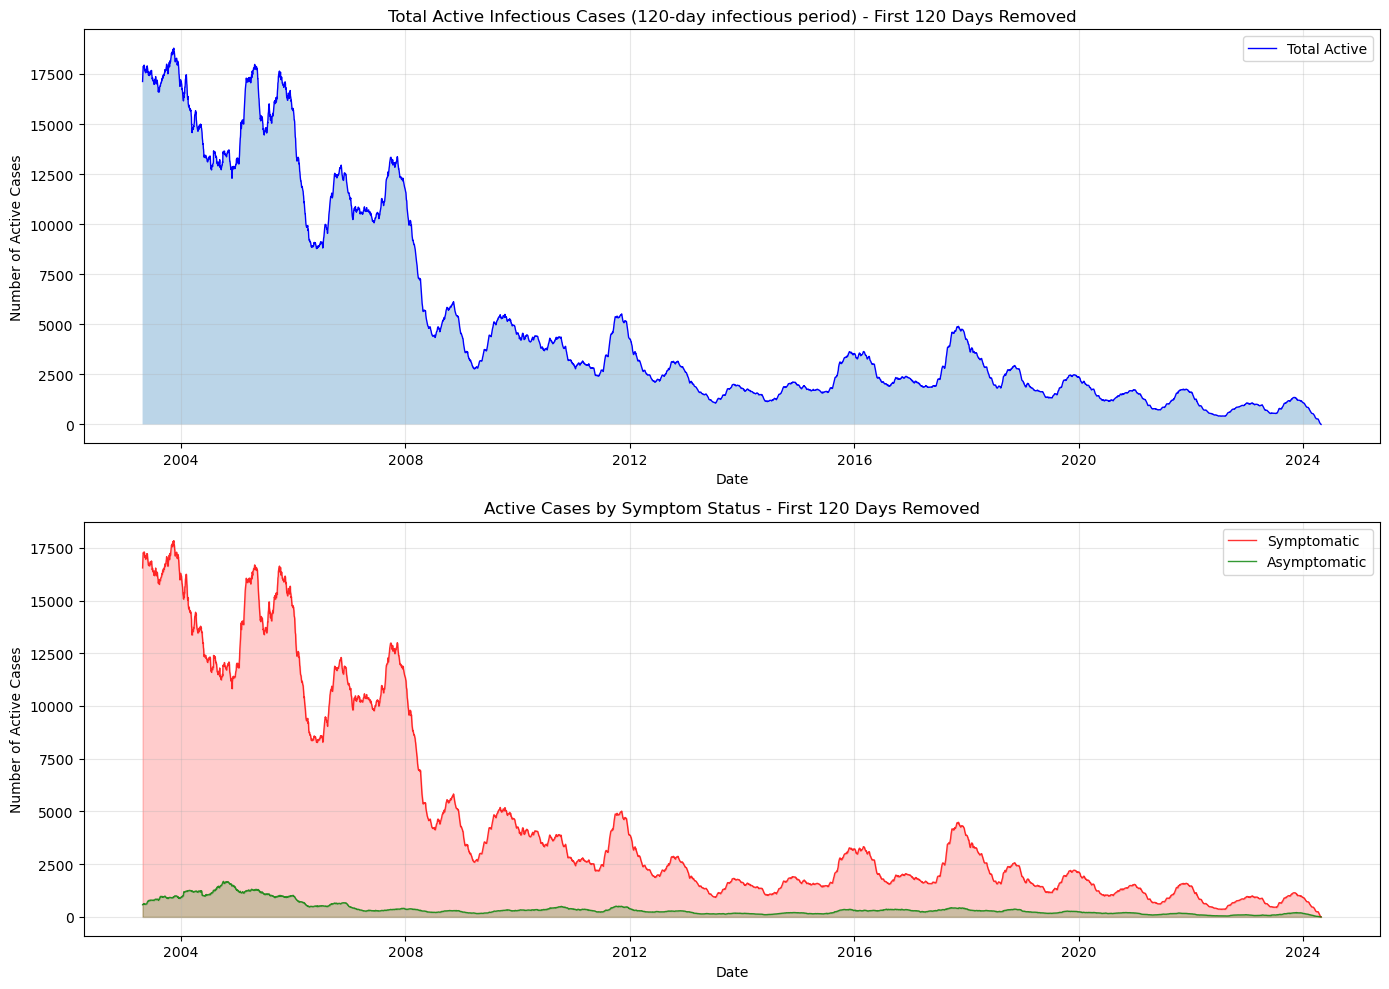


=== SUMMARY STATISTICS (First 120 Days Removed) ===
Period: 2003-04-26 to 2024-04-27

Active Cases Statistics (trimmed):
  Average daily active: 5067
  Peak daily active: 18,789
  Peak date: 2003-11-15


In [8]:
# After creating daily_active_cases_detailed, drop the first 120 days

# Remove the first 120 days to eliminate the artificial ramp-up period
daily_active_cases_detailed_trimmed = daily_active_cases_detailed.iloc[120:].reset_index(drop=True)

print(f"Original data range: {daily_active_cases_detailed['date'].min()} to {daily_active_cases_detailed['date'].max()}")
print(f"Trimmed data range: {daily_active_cases_detailed_trimmed['date'].min()} to {daily_active_cases_detailed_trimmed['date'].max()}")
print(f"Rows removed: 120")
print(f"Remaining rows: {len(daily_active_cases_detailed_trimmed):,}")

# Plot the trimmed results
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot total active cases (trimmed)
axes[0].plot(daily_active_cases_detailed_trimmed['date'], 
             daily_active_cases_detailed_trimmed['active_total'], 
             color='blue', linewidth=1, label='Total Active')
axes[0].fill_between(daily_active_cases_detailed_trimmed['date'], 0, 
                     daily_active_cases_detailed_trimmed['active_total'], alpha=0.3)
axes[0].set_title('Total Active Infectious Cases (120-day infectious period) - First 120 Days Removed')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Active Cases')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot symptomatic vs asymptomatic (trimmed)
axes[1].plot(daily_active_cases_detailed_trimmed['date'], 
             daily_active_cases_detailed_trimmed['active_symptomatic'], 
             color='red', linewidth=1, label='Symptomatic', alpha=0.8)
axes[1].plot(daily_active_cases_detailed_trimmed['date'], 
             daily_active_cases_detailed_trimmed['active_asymptomatic'], 
             color='green', linewidth=1, label='Asymptomatic', alpha=0.8)
axes[1].fill_between(daily_active_cases_detailed_trimmed['date'], 0, 
                     daily_active_cases_detailed_trimmed['active_symptomatic'], 
                     color='red', alpha=0.2)
axes[1].fill_between(daily_active_cases_detailed_trimmed['date'], 0, 
                     daily_active_cases_detailed_trimmed['active_asymptomatic'], 
                     color='green', alpha=0.2)
axes[1].set_title('Active Cases by Symptom Status - First 120 Days Removed')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Active Cases')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary statistics for trimmed data
print("\n=== SUMMARY STATISTICS (First 120 Days Removed) ===")
print(f"Period: {daily_active_cases_detailed_trimmed['date'].min().date()} to {daily_active_cases_detailed_trimmed['date'].max().date()}")
print(f"\nActive Cases Statistics (trimmed):")
print(f"  Average daily active: {daily_active_cases_detailed_trimmed['active_total'].mean():.0f}")
print(f"  Peak daily active: {daily_active_cases_detailed_trimmed['active_total'].max():,}")
print(f"  Peak date: {daily_active_cases_detailed_trimmed.loc[daily_active_cases_detailed_trimmed['active_total'].idxmax(), 'date'].date()}")

In [9]:
def aggregate_with_infectious_period_and_carryover(df, infectious_days=120, start_year=2016, end_year=2024):
    """
    Aggregate cases considering infectious period, including carryover from previous year.
    Handles both symptomatic and asymptomatic cases.
    """
    
    # Make a copy
    df = df.copy()
    
    # Ensure datetime for date columns
    date_columns = ['DT_SINTO', 'DT_NOTIF']
    for col in date_columns:
        if col in df.columns and df[col].dtype != 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Include previous year for carryover calculation
    df_extended = df[(df['DT_NOTIF'].dt.year >= start_year - 1) & 
                     (df['DT_NOTIF'].dt.year <= end_year)].copy()
    
    print(f"\n=== Processing {start_year}-{end_year} Data (with carryover from {start_year-1}) ===")
    print(f"Total cases in extended range: {len(df_extended):,}")
    
    # Create a unified infection start date column
    df_extended['infection_start'] = df_extended['DT_SINTO'].copy()
    
    # For asymptomatic or missing symptom date, use notification date
    asymptomatic_mask = (df_extended['SINTOMAS'] == 2) | (df_extended['DT_SINTO'].isna())
    df_extended.loc[asymptomatic_mask, 'infection_start'] = df_extended.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Ensure datetime format for infection_start
    if df_extended['infection_start'].dtype != 'datetime64[ns]':
        df_extended['infection_start'] = pd.to_datetime(df_extended['infection_start'], errors='coerce')
    
    # Drop only rows where infection_start is completely invalid
    df_extended = df_extended.dropna(subset=['infection_start'])
    
    print(f"Valid cases after processing: {len(df_extended):,}")
    print(f"  - Symptomatic (using DT_SINTO): {(df_extended['SINTOMAS'] == 1).sum():,}")
    print(f"  - Asymptomatic (using DT_NOTIF): {(df_extended['SINTOMAS'] == 2).sum():,}")
    
    # Create date range covering the entire period
    min_date = df_extended['infection_start'].min()
    max_date = df_extended['infection_start'].max() + pd.Timedelta(days=infectious_days)
    date_range = pd.date_range(start=min_date, end=max_date, freq='D')
    
    print(f"\nDate range: {min_date.date()} to {max_date.date()} ({len(date_range):,} days)")
    
    # Separate symptomatic and asymptomatic
    symptomatic_df = df_extended[df_extended['SINTOMAS'] == 1].copy()
    asymptomatic_df = df_extended[df_extended['SINTOMAS'] == 2].copy()
    
    # Function to count active cases for a subset
    def count_active(subset_df):
        if len(subset_df) == 0:
            return np.zeros(len(date_range), dtype=int)
        
        start_dates = subset_df['infection_start'].values
        end_dates = start_dates + np.timedelta64(infectious_days, 'D')
        active = np.zeros(len(date_range), dtype=int)
        
        for start, end in zip(start_dates, end_dates):
            mask = (date_range >= start) & (date_range < end)
            active[mask] += 1
        
        return active
    
    # Count active cases for each group
    print("\nCalculating active cases...")
    active_symptomatic = count_active(symptomatic_df)
    active_asymptomatic = count_active(asymptomatic_df)
    active_total = active_symptomatic + active_asymptomatic
    
    # Create detailed result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_total': active_total,
        'active_symptomatic': active_symptomatic,
        'active_asymptomatic': active_asymptomatic
    })
    
    # Filter to only show results from start_year onward
    result_df_filtered = result_df[result_df['date'].dt.year >= start_year].copy()
    result_df_filtered = result_df_filtered.reset_index(drop=True)
    
    # Find peak date
    if len(result_df_filtered) > 0:
        peak_idx = result_df_filtered['active_total'].idxmax()
        peak_date = result_df_filtered.loc[peak_idx, 'date']
        
        print(f"\n=== Results for {start_year}-{end_year} (including carryover) ===")
        print(f"  Average daily active: {result_df_filtered['active_total'].mean():.0f}")
        print(f"  Peak total active: {result_df_filtered['active_total'].max():,}")
        print(f"  Peak symptomatic: {result_df_filtered['active_symptomatic'].max():,}")
        print(f"  Peak asymptomatic: {result_df_filtered['active_asymptomatic'].max():,}")
        print(f"  Peak date: {peak_date.date()}")
        print(f"  Active cases on first day ({result_df_filtered['date'].min().date()}): {result_df_filtered['active_total'].iloc[0]:,}")
    
    return result_df_filtered

# Apply with carryover from 2015
daily_active_cases_2016_2024_with_carryover = aggregate_with_infectious_period_and_carryover(
    manaus_malaria_data, 
    infectious_days=120, 
    start_year=2016, 
    end_year=2024
)


=== Processing 2016-2024 Data (with carryover from 2015) ===
Total cases in extended range: 51,562
Valid cases after processing: 51,562
  - Symptomatic (using DT_SINTO): 45,666
  - Asymptomatic (using DT_NOTIF): 5,896

Date range: 2014-12-25 to 2024-04-27 (3,412 days)

Calculating active cases...

=== Results for 2016-2024 (including carryover) ===
  Average daily active: 1801
  Peak total active: 4,897
  Peak symptomatic: 4,486
  Peak asymptomatic: 437
  Peak date: 2017-11-09
  Active cases on first day (2016-01-01): 3,528


In [10]:
def aggregate_with_prior_period(df, infectious_days=120, start_year=2016, end_year=2023):
    """
    Aggregate cases considering infectious period, including cases from prior period.
    This ensures accurate active case counts at the beginning of the study period.
    """
    
    # Make a copy
    df = df.copy()
    
    # Ensure datetime for date columns
    date_columns = ['DT_SINTO', 'DT_NOTIF']
    for col in date_columns:
        if col in df.columns and df[col].dtype != 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Calculate the start date for prior period (120 days before start_year)
    prior_start_date = pd.Timestamp(year=start_year, month=1, day=1) - pd.Timedelta(days=infectious_days)
    
    # Include prior period cases (from start_year-1 to ensure we capture all that could be active)
    # Actually, we need cases that could still be infectious on Jan 1 of start_year
    df_extended = df[(df['DT_NOTIF'] >= prior_start_date) & (df['DT_NOTIF'].dt.year <= end_year)].copy()
    
    print(f"\n=== Processing {start_year}-{end_year} with {infectious_days} days prior ===")
    print(f"Prior period start: {prior_start_date.date()}")
    print(f"Total cases in extended range: {len(df_extended):,}")
    print(f"  - Cases from prior period ({prior_start_date.year}): {(df_extended['DT_NOTIF'].dt.year == prior_start_date.year).sum():,}")
    
    # Create a unified infection start date column
    df_extended['infection_start'] = df_extended['DT_SINTO'].copy()
    
    # For asymptomatic or missing symptom date, use notification date
    asymptomatic_mask = (df_extended['SINTOMAS'] == 2) | (df_extended['DT_SINTO'].isna())
    df_extended.loc[asymptomatic_mask, 'infection_start'] = df_extended.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Ensure datetime format for infection_start
    if df_extended['infection_start'].dtype != 'datetime64[ns]':
        df_extended['infection_start'] = pd.to_datetime(df_extended['infection_start'], errors='coerce')
    
    # Drop only rows where infection_start is completely invalid
    df_extended = df_extended.dropna(subset=['infection_start'])
    
    print(f"Valid cases after processing: {len(df_extended):,}")
    print(f"  - Symptomatic (using DT_SINTO): {(df_extended['SINTOMAS'] == 1).sum():,}")
    print(f"  - Asymptomatic (using DT_NOTIF): {(df_extended['SINTOMAS'] == 2).sum():,}")
    
    # Create date range covering the entire period (from prior_start_date to end)
    min_date = df_extended['infection_start'].min()
    max_date = df_extended['infection_start'].max() + pd.Timedelta(days=infectious_days)
    date_range = pd.date_range(start=min_date, end=max_date, freq='D')
    
    print(f"\nDate range: {min_date.date()} to {max_date.date()} ({len(date_range):,} days)")
    
    # Separate symptomatic and asymptomatic
    symptomatic_df = df_extended[df_extended['SINTOMAS'] == 1].copy()
    asymptomatic_df = df_extended[df_extended['SINTOMAS'] == 2].copy()
    
    # Function to count active cases for a subset
    def count_active(subset_df):
        if len(subset_df) == 0:
            return np.zeros(len(date_range), dtype=int)
        
        start_dates = subset_df['infection_start'].values
        end_dates = start_dates + np.timedelta64(infectious_days, 'D')
        active = np.zeros(len(date_range), dtype=int)
        
        print(f"    Processing {len(subset_df):,} cases...")
        for i, (start, end) in enumerate(zip(start_dates, end_dates)):
            mask = (date_range >= start) & (date_range < end)
            active[mask] += 1
            
            # Print progress every 50,000 cases
            if (i + 1) % 50000 == 0:
                print(f"      Processed {i+1:,}/{len(subset_df):,} cases")
        
        return active
    
    # Count active cases for each group
    print("\nCalculating active cases...")
    print("  Processing symptomatic cases...")
    active_symptomatic = count_active(symptomatic_df)
    print("  Processing asymptomatic cases...")
    active_asymptomatic = count_active(asymptomatic_df)
    active_total = active_symptomatic + active_asymptomatic
    
    # Create detailed result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_total': active_total,
        'active_symptomatic': active_symptomatic,
        'active_asymptomatic': active_asymptomatic
    })
    
    # Filter to only show results from start_year onward
    result_df_filtered = result_df[result_df['date'].dt.year >= start_year].copy()
    result_df_filtered = result_df_filtered.reset_index(drop=True)
    
    # Find peak date
    if len(result_df_filtered) > 0:
        peak_idx = result_df_filtered['active_total'].idxmax()
        peak_date = result_df_filtered.loc[peak_idx, 'date']
        
        print(f"\n=== Results for {start_year}-{end_year} (including {infectious_days}-day prior period) ===")
        print(f"  Average daily active: {result_df_filtered['active_total'].mean():.0f}")
        print(f"  Peak total active: {result_df_filtered['active_total'].max():,}")
        print(f"  Peak symptomatic: {result_df_filtered['active_symptomatic'].max():,}")
        print(f"  Peak asymptomatic: {result_df_filtered['active_asymptomatic'].max():,}")
        print(f"  Peak date: {peak_date.date()}")
        print(f"  Active cases on first day ({result_df_filtered['date'].min().date()}): {result_df_filtered['active_total'].iloc[0]:,}")
    
    return result_df_filtered

# Apply with 120 days prior to 2016
daily_active_cases_2016_2023_with_prior = aggregate_with_prior_period(
    manaus_malaria_data, 
    infectious_days=120, 
    start_year=2016, 
    end_year=2023
)


=== Processing 2016-2023 with 120 days prior ===
Prior period start: 2015-09-03
Total cases in extended range: 47,439
  - Cases from prior period (2015): 3,521
Valid cases after processing: 47,439
  - Symptomatic (using DT_SINTO): 41,952
  - Asymptomatic (using DT_NOTIF): 5,487

Date range: 2015-08-16 to 2024-04-27 (3,178 days)

Calculating active cases...
  Processing symptomatic cases...
    Processing 41,952 cases...
  Processing asymptomatic cases...
    Processing 5,487 cases...

=== Results for 2016-2023 (including 120-day prior period) ===
  Average daily active: 1801
  Peak total active: 4,897
  Peak symptomatic: 4,486
  Peak asymptomatic: 437
  Peak date: 2017-11-09
  Active cases on first day (2016-01-01): 3,520


C:\Users\rapha\AppData\Local\Temp\ipykernel_10000\3053905931.py:37: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = daily_active_cases_2016_2023_with_prior.set_index('date').resample('M').mean()


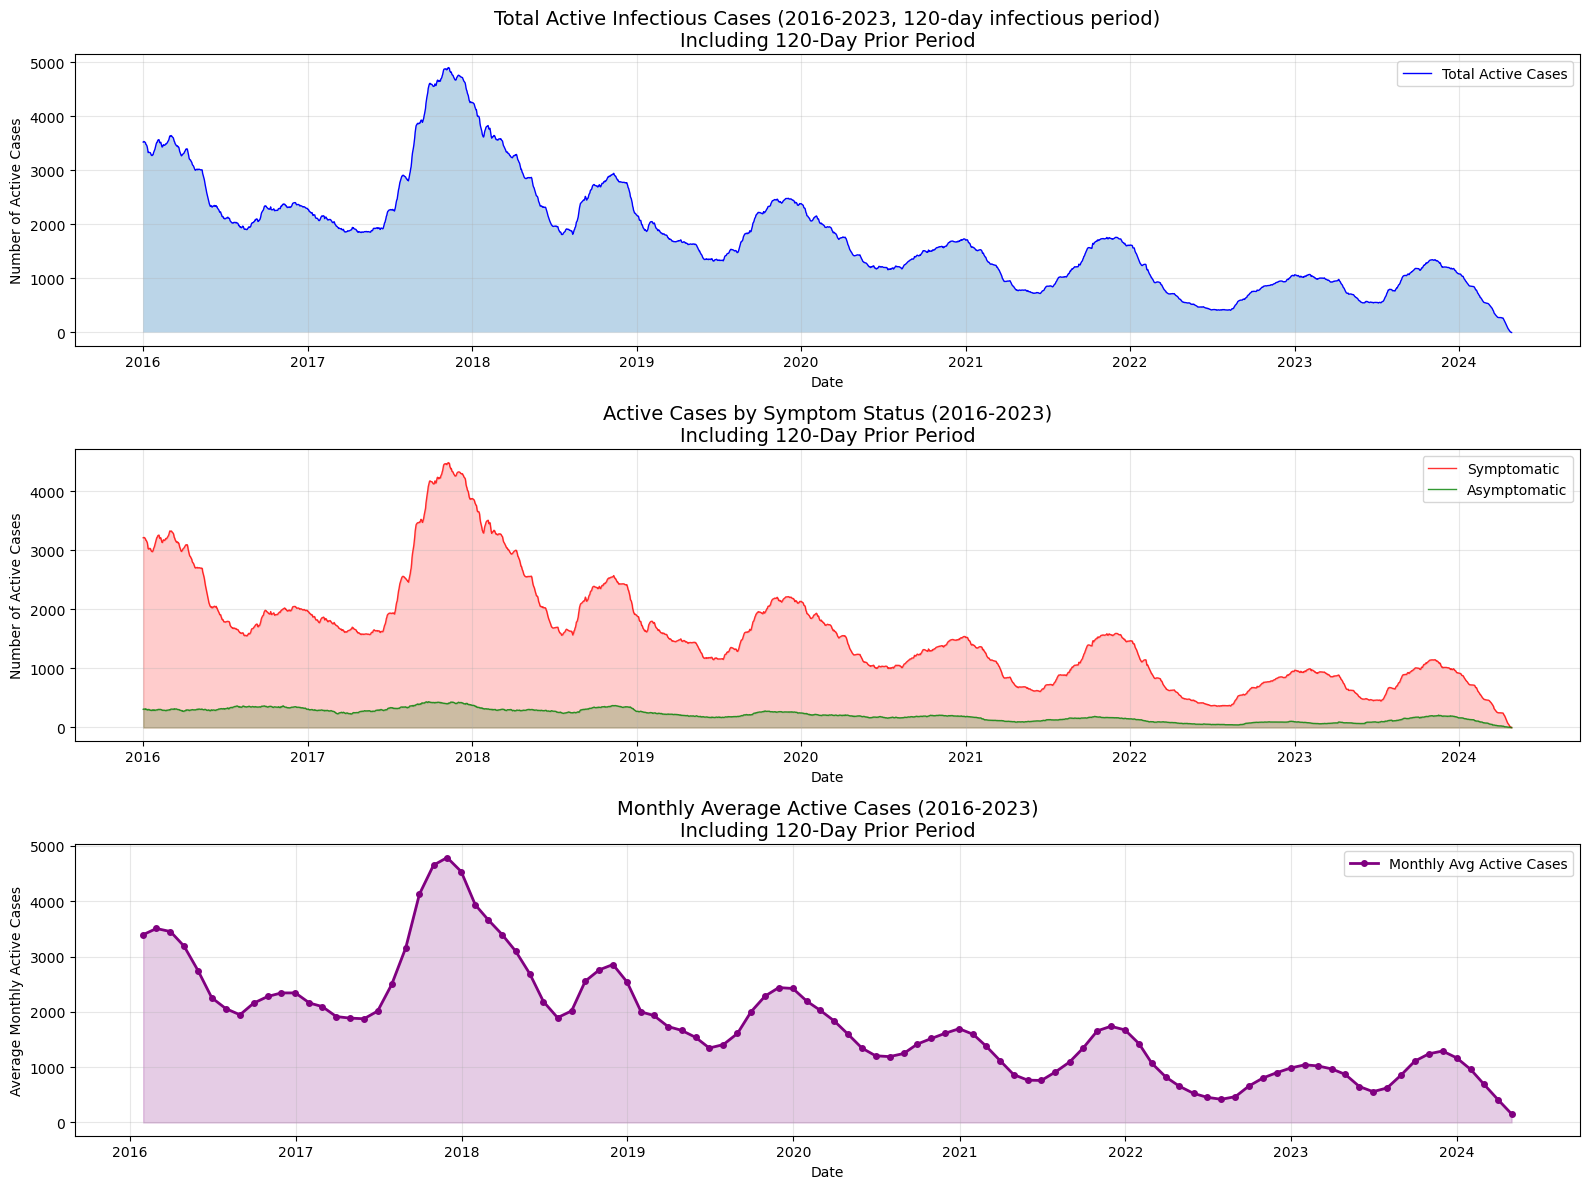

In [11]:
# Plot the results
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: Total active cases
axes[0].plot(daily_active_cases_2016_2023_with_prior['date'], 
             daily_active_cases_2016_2023_with_prior['active_total'], 
             color='blue', linewidth=1, label='Total Active Cases')
axes[0].fill_between(daily_active_cases_2016_2023_with_prior['date'], 0, 
                     daily_active_cases_2016_2023_with_prior['active_total'], alpha=0.3)
axes[0].set_title('Total Active Infectious Cases (2016-2023, 120-day infectious period)\nIncluding 120-Day Prior Period', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Active Cases')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Symptomatic vs Asymptomatic
axes[1].plot(daily_active_cases_2016_2023_with_prior['date'], 
             daily_active_cases_2016_2023_with_prior['active_symptomatic'], 
             color='red', linewidth=1, label='Symptomatic', alpha=0.8)
axes[1].plot(daily_active_cases_2016_2023_with_prior['date'], 
             daily_active_cases_2016_2023_with_prior['active_asymptomatic'], 
             color='green', linewidth=1, label='Asymptomatic', alpha=0.8)
axes[1].fill_between(daily_active_cases_2016_2023_with_prior['date'], 0, 
                     daily_active_cases_2016_2023_with_prior['active_symptomatic'], 
                     color='red', alpha=0.2)
axes[1].fill_between(daily_active_cases_2016_2023_with_prior['date'], 0, 
                     daily_active_cases_2016_2023_with_prior['active_asymptomatic'], 
                     color='green', alpha=0.2)
axes[1].set_title('Active Cases by Symptom Status (2016-2023)\nIncluding 120-Day Prior Period', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Active Cases')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot 3: Monthly averages
# Resample to monthly for smoother view
monthly_avg = daily_active_cases_2016_2023_with_prior.set_index('date').resample('M').mean()

axes[2].plot(monthly_avg.index, monthly_avg['active_total'], 
             color='purple', linewidth=2, marker='o', markersize=4, label='Monthly Avg Active Cases')
axes[2].fill_between(monthly_avg.index, 0, monthly_avg['active_total'], alpha=0.2, color='purple')
axes[2].set_title('Monthly Average Active Cases (2016-2023)\nIncluding 120-Day Prior Period', fontsize=14)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Average Monthly Active Cases')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

In [12]:
# Ensure DT_NOTIF is datetime
if manaus_malaria_data['DT_NOTIF'].dtype != 'datetime64[ns]':
    manaus_malaria_data['DT_NOTIF'] = pd.to_datetime(manaus_malaria_data['DT_NOTIF'], errors='coerce')
    print("Converted DT_NOTIF to datetime")

# Verify the conversion
print(f"DT_NOTIF dtype: {manaus_malaria_data['DT_NOTIF'].dtype}")
print(f"DT_NOTIF sample:\n{manaus_malaria_data['DT_NOTIF'].head()}")

Converted DT_NOTIF to datetime
DT_NOTIF dtype: datetime64[ns]
DT_NOTIF sample:
6    2003-10-13
7    2003-10-10
8    2003-10-10
9    2003-03-25
10   2003-07-11
Name: DT_NOTIF, dtype: datetime64[ns]


C:\Users\rapha\AppData\Local\Temp\ipykernel_10000\1683177116.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  manaus_malaria_data['DT_NOTIF'] = pd.to_datetime(manaus_malaria_data['DT_NOTIF'], errors='coerce')


In [13]:
def calculate_active_cases_with_prior_period(df, infectious_days=120, start_year=2016, end_year=2023):
    """
    Calculate active cases including prior period for accurate initial counts,
    then trim the first infectious_days days.
    """
    
    # Make a copy
    df = df.copy()
    
    # Ensure datetime for date columns
    date_columns = ['DT_SINTO', 'DT_NOTIF']
    for col in date_columns:
        if col in df.columns and df[col].dtype != 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Calculate the start date (120 days before start_year)
    prior_start_date = pd.Timestamp(year=start_year, month=1, day=1) - pd.Timedelta(days=infectious_days)
    end_date = pd.Timestamp(year=end_year, month=12, day=31) + pd.Timedelta(days=infectious_days)
    
    # Include prior period cases
    df_extended = df[(df['DT_NOTIF'] >= prior_start_date) & (df['DT_NOTIF'] <= end_date)].copy()
    
    print(f"\n=== Including {infectious_days} days prior to {start_year} ===")
    print(f"Prior period start: {prior_start_date.date()}")
    print(f"Total cases in extended range: {len(df_extended):,}")
    print(f"  - Cases from prior period: {(df_extended['DT_NOTIF'] < pd.Timestamp(year=start_year, month=1, day=1)).sum():,}")
    
    # Create unified infection start date
    df_extended['infection_start'] = df_extended['DT_SINTO'].copy()
    asymptomatic_mask = (df_extended['SINTOMAS'] == 2) | (df_extended['DT_SINTO'].isna())
    df_extended.loc[asymptomatic_mask, 'infection_start'] = df_extended.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Ensure datetime format
    if df_extended['infection_start'].dtype != 'datetime64[ns]':
        df_extended['infection_start'] = pd.to_datetime(df_extended['infection_start'], errors='coerce')
    
    df_extended = df_extended.dropna(subset=['infection_start'])
    
    # Create date range from prior_start_date to end
    date_range = pd.date_range(start=prior_start_date, end=end_date, freq='D')
    
    print(f"\nDate range: {date_range.min().date()} to {date_range.max().date()} ({len(date_range):,} days)")
    
    # Separate symptomatic and asymptomatic
    symptomatic_df = df_extended[df_extended['SINTOMAS'] == 1].copy()
    asymptomatic_df = df_extended[df_extended['SINTOMAS'] == 2].copy()
    
    # Function to count active cases
    def count_active(subset_df):
        if len(subset_df) == 0:
            return np.zeros(len(date_range), dtype=int)
        
        start_dates = subset_df['infection_start'].values
        end_dates = start_dates + np.timedelta64(infectious_days, 'D')
        active = np.zeros(len(date_range), dtype=int)
        
        for start, end in zip(start_dates, end_dates):
            mask = (date_range >= start) & (date_range < end)
            active[mask] += 1
        
        return active
    
    # Count active cases
    print("\nCalculating active cases...")
    active_symptomatic = count_active(symptomatic_df)
    active_asymptomatic = count_active(asymptomatic_df)
    active_total = active_symptomatic + active_asymptomatic
    
    # Create result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_total': active_total,
        'active_symptomatic': active_symptomatic,
        'active_asymptomatic': active_asymptomatic
    })
    
    return result_df

# Calculate active cases including prior period
daily_active_cases_full = calculate_active_cases_with_prior_period(
    manaus_malaria_data, 
    infectious_days=120, 
    start_year=2016, 
    end_year=2023
)


=== Including 120 days prior to 2016 ===
Prior period start: 2015-09-03
Total cases in extended range: 47,439
  - Cases from prior period: 3,521

Date range: 2015-09-03 to 2024-04-29 (3,162 days)

Calculating active cases...


In [14]:
# Calculate new cases per day based on infection start
# First, create a function to get infection start for all cases
def get_infection_start(row):
    if row['SINTOMAS'] == 2 or pd.isna(row['DT_SINTO']):
        return row['DT_NOTIF']
    else:
        return row['DT_SINTO']

# Apply to get infection start for all cases in Manaus
manaus_malaria_data_with_start = manaus_malaria_data.copy()
manaus_malaria_data_with_start['infection_start'] = manaus_malaria_data_with_start.apply(get_infection_start, axis=1)

# Ensure datetime
if manaus_malaria_data_with_start['infection_start'].dtype != 'datetime64[ns]':
    manaus_malaria_data_with_start['infection_start'] = pd.to_datetime(
        manaus_malaria_data_with_start['infection_start'], errors='coerce'
    )

# Calculate new cases per day (based on infection start)
daily_new_cases = manaus_malaria_data_with_start.groupby(
    manaus_malaria_data_with_start['infection_start'].dt.floor('D')
).size()

# Reindex to match full date range
daily_new_cases = daily_new_cases.reindex(daily_active_cases_full['date'], fill_value=0)

# Add new cases and cumulative cases to the full dataframe
daily_active_cases_full['new_cases'] = daily_new_cases.values
daily_active_cases_full['cumulative_cases'] = daily_new_cases.cumsum().values

print(f"\nFull data range: {daily_active_cases_full['date'].min().date()} to {daily_active_cases_full['date'].max().date()}")
print(f"Total cumulative cases (full range): {daily_active_cases_full['cumulative_cases'].max():,.0f}")


Full data range: 2015-09-03 to 2024-04-29
Total cumulative cases (full range): 47,433


In [15]:
# Trim the first 120 days (the prior period)
daily_active_cases_trimmed = daily_active_cases_full.iloc[120:].reset_index(drop=True)

print(f"\n=== After Trimming First 120 Days ===")
print(f"Original rows: {len(daily_active_cases_full)}")
print(f"Trimmed rows: {len(daily_active_cases_trimmed)}")
print(f"Trimmed date range: {daily_active_cases_trimmed['date'].min().date()} to {daily_active_cases_trimmed['date'].max().date()}")
print(f"Active cases on first trimmed day: {daily_active_cases_trimmed['active_total'].iloc[0]:,.0f}")


=== After Trimming First 120 Days ===
Original rows: 3162
Trimmed rows: 3042
Trimmed date range: 2016-01-01 to 2024-04-29
Active cases on first trimmed day: 3,520


In [16]:
# Check the first few days of 2016
jan_2016 = daily_active_cases_trimmed[
    (daily_active_cases_trimmed['date'] >= '2016-01-01') & 
    (daily_active_cases_trimmed['date'] <= '2016-01-10')
]

print("\n=== Active Cases at Beginning of 2016 (After Trimming) ===")
print(jan_2016[['date', 'active_total', 'new_cases', 'cumulative_cases']].head(10))

# Compare with the old approach that started at 2016-01-01
print(f"\nActive cases on Jan 1, 2016 (with prior period): {daily_active_cases_trimmed[daily_active_cases_trimmed['date'] == '2016-01-01']['active_total'].iloc[0]:,.0f}")


=== Active Cases at Beginning of 2016 (After Trimming) ===
        date  active_total  new_cases  cumulative_cases
0 2016-01-01          3520          3              3531
1 2016-01-02          3529         17              3548
2 2016-01-03          3530          5              3553
3 2016-01-04          3525          4              3557
4 2016-01-05          3515          0              3557
5 2016-01-06          3509         10              3567
6 2016-01-07          3478          6              3573
7 2016-01-08          3470          6              3579
8 2016-01-09          3455          6              3585
9 2016-01-10          3428          0              3585

Active cases on Jan 1, 2016 (with prior period): 3,520


In [17]:
# Create final dataframe with all metrics
final_df = daily_active_cases_trimmed.copy()

# Add year, month, week columns for easier analysis
final_df['year'] = final_df['date'].dt.year
final_df['month'] = final_df['date'].dt.month
final_df['week'] = final_df['date'].dt.isocalendar().week
final_df['day_of_year'] = final_df['date'].dt.dayofyear

# Calculate additional metrics
final_df['active_per_new_case'] = final_df['active_total'] / (final_df['new_cases'] + 1)

# Save the final dataframe
final_df.to_csv("../../data_files/data/sivep_notification_data/treated_malaria_notification_data/cumulative_manaus_cases_2016_2023.csv", index=False)
print(f"\nSaved final dataframe: active_cases_2016_2023_with_cumulative.csv")
print(f"File has {len(final_df):,} rows and {len(final_df.columns)} columns")

# Preview
print("\nFirst 10 rows of final dataframe:")
print(final_df[['date', 'new_cases', 'active_total', 'cumulative_cases']].head(10))

print("\nLast 10 rows of final dataframe:")
print(final_df[['date', 'new_cases', 'active_total', 'cumulative_cases']].tail(10))


Saved final dataframe: active_cases_2016_2023_with_cumulative.csv
File has 3,042 rows and 11 columns

First 10 rows of final dataframe:
        date  new_cases  active_total  cumulative_cases
0 2016-01-01          3          3520              3531
1 2016-01-02         17          3529              3548
2 2016-01-03          5          3530              3553
3 2016-01-04          4          3525              3557
4 2016-01-05          0          3515              3557
5 2016-01-06         10          3509              3567
6 2016-01-07          6          3478              3573
7 2016-01-08          6          3470              3579
8 2016-01-09          6          3455              3585
9 2016-01-10          0          3428              3585

Last 10 rows of final dataframe:
           date  new_cases  active_total  cumulative_cases
3032 2024-04-20          0            62             47433
3033 2024-04-21          0            51             47433
3034 2024-04-22          0          

In [18]:
# Summary statistics
print("\n=== FINAL SUMMARY STATISTICS (2016-2023, After Trimming) ===")
print(f"Period: {final_df['date'].min().date()} to {final_df['date'].max().date()}")
print(f"Total days: {len(final_df):,}")
print(f"\nTotal new cases: {final_df['new_cases'].sum():,.0f}")
print(f"Total cumulative cases: {final_df['cumulative_cases'].max():,.0f}")
print(f"\nActive Cases Statistics:")
print(f"  Average daily active: {final_df['active_total'].mean():.0f}")
print(f"  Median daily active: {final_df['active_total'].median():.0f}")
print(f"  Peak daily active: {final_df['active_total'].max():,}")
print(f"  Peak date: {final_df.loc[final_df['active_total'].idxmax(), 'date'].date()}")
print(f"\nSymptomatic vs Asymptomatic:")
print(f"  Average symptomatic: {final_df['active_symptomatic'].mean():.0f}")
print(f"  Average asymptomatic: {final_df['active_asymptomatic'].mean():.0f}")
print(f"  Symptomatic/Asymptomatic ratio: {final_df['active_symptomatic'].mean() / final_df['active_asymptomatic'].mean():.2f}")

# Yearly summary
yearly_summary = final_df.groupby('year').agg({
    'new_cases': 'sum',
    'active_total': ['mean', 'max'],
    'cumulative_cases': 'last'
}).round(0)
yearly_summary.columns = ['total_new_cases', 'avg_daily_active', 'peak_active', 'cumulative_end']
print("\n=== YEARLY SUMMARY ===")
print(yearly_summary)

# Save yearly summary
yearly_summary.to_csv('../../data_files/data/sivep_notification_data/treated_malaria_notification_data/yearly_summary_2016_2023.csv')
print("\nSaved yearly summary: yearly_summary_2016_2023.csv")


=== FINAL SUMMARY STATISTICS (2016-2023, After Trimming) ===
Period: 2016-01-01 to 2024-04-29
Total days: 3,042

Total new cases: 43,905
Total cumulative cases: 47,433

Active Cases Statistics:
  Average daily active: 1800
  Median daily active: 1678
  Peak daily active: 4,897
  Peak date: 2017-11-09

Symptomatic vs Asymptomatic:
  Average symptomatic: 1591
  Average asymptomatic: 210
  Symptomatic/Asymptomatic ratio: 7.59

=== YEARLY SUMMARY ===
      total_new_cases  avg_daily_active  peak_active  cumulative_end
year                                                                
2016             7376            2636.0         3640           10904
2017             9987            2981.0         4897           20891
2018             7474            2795.0         4250           28365
2019             5861            1866.0         2480           34226
2020             4508            1573.0         2383           38734
2021             3615            1242.0         1759           42

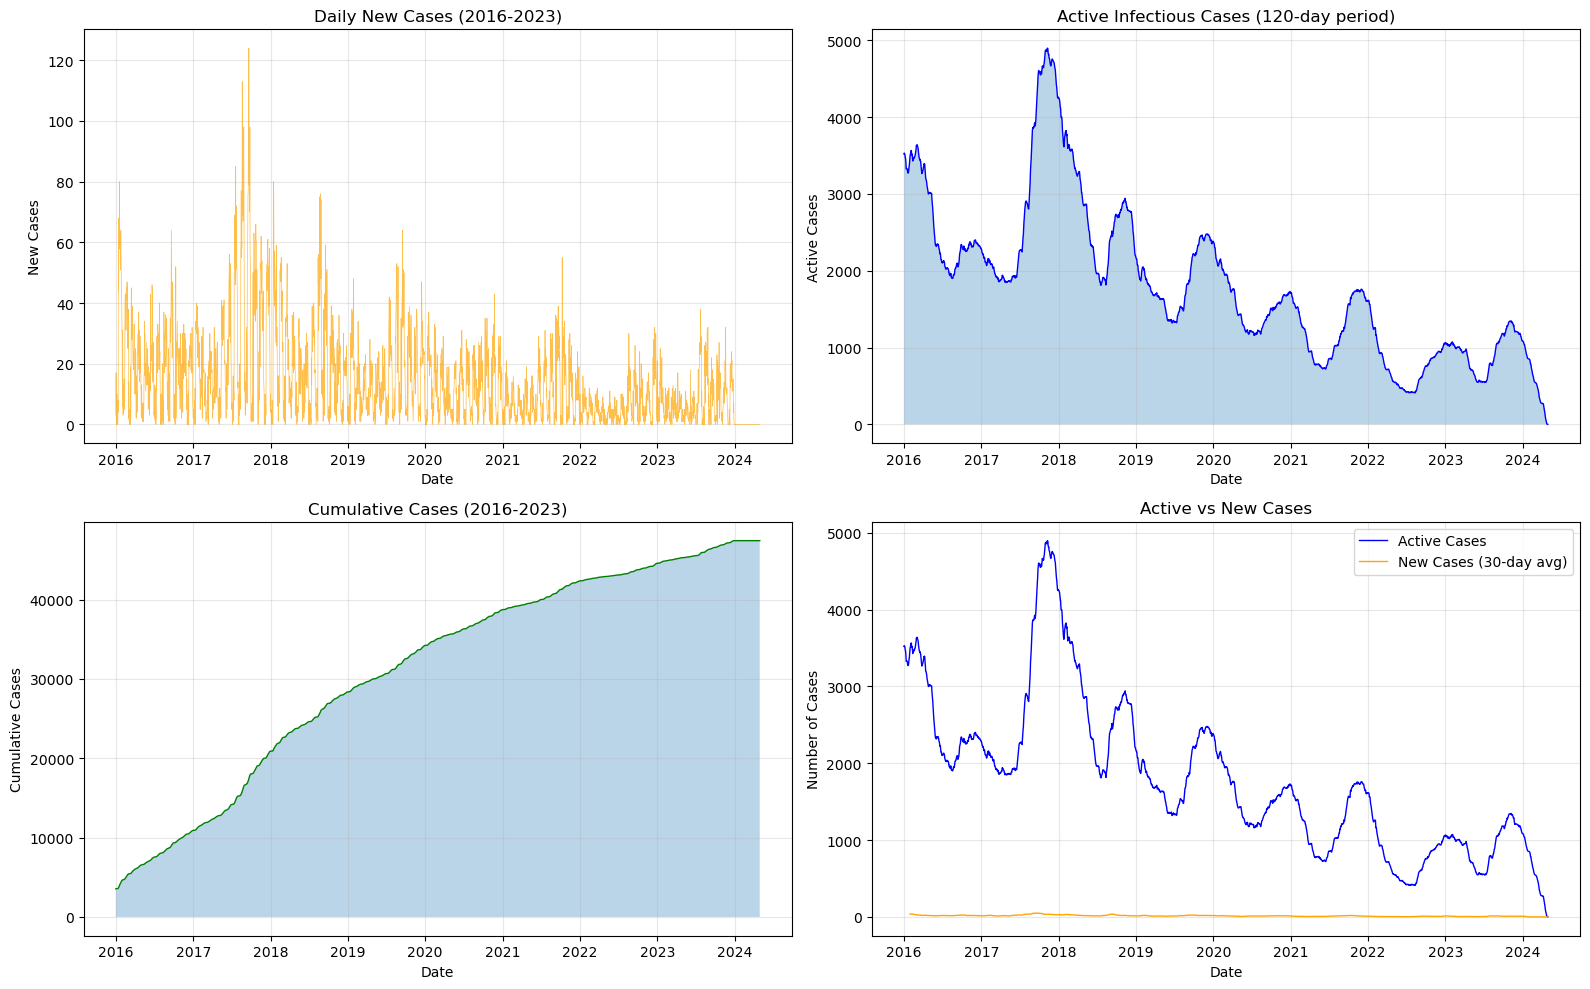

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Daily new cases
axes[0, 0].plot(final_df['date'], final_df['new_cases'], color='orange', linewidth=0.5, alpha=0.7)
axes[0, 0].set_title('Daily New Cases (2016-2023)', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('New Cases')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Active cases
axes[0, 1].plot(final_df['date'], final_df['active_total'], color='blue', linewidth=1)
axes[0, 1].fill_between(final_df['date'], 0, final_df['active_total'], alpha=0.3)
axes[0, 1].set_title('Active Infectious Cases (120-day period)', fontsize=12)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Active Cases')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Cumulative cases
axes[1, 0].plot(final_df['date'], final_df['cumulative_cases'], color='green', linewidth=1)
axes[1, 0].fill_between(final_df['date'], 0, final_df['cumulative_cases'], alpha=0.3)
axes[1, 0].set_title('Cumulative Cases (2016-2023)', fontsize=12)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Cumulative Cases')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Active vs New Cases (with rolling average)
axes[1, 1].plot(final_df['date'], final_df['active_total'], label='Active Cases', color='blue', linewidth=1)
axes[1, 1].plot(final_df['date'], final_df['new_cases'].rolling(30).mean(), 
                label='New Cases (30-day avg)', color='orange', linewidth=1)
axes[1, 1].set_title('Active vs New Cases', fontsize=12)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Number of Cases')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()